In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplcursors
from matplotlib.animation import FuncAnimation, PillowWriter
from astropy.time import Time
from IPython.display import HTML
from lmfit.models import GaussianModel, VoigtModel, ConstantModel
#from scipy.signal import find_peaks
#import numpy.polynomial.polynomial as poly
#from numpy.polynomial import Polynomial
#import scipy.constants as const

In [2]:
#Datos de Julio, Agosto y Septiembre del 2026

ruta_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares 6563 julio 22.xlsx"

ruta_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares agosto 26 orden 1.xlsx"

ruta_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares septiembre 6 orden 1.xlsx"

antares_julio = pd.read_excel(ruta_julio, sheet_name="ster 6563 normaliz", usecols=[0, 1, 2, 3], header=None, names =["pixel", "intensidad_e", "no se", "flujo normalizado"])

print("--- Julio---")
display(antares_julio.head())


--- Julio---


,pixel,intensidad_e,no se,flujo normalizado
0,0,23974,29866,0.802719
1,1,23697,29801,0.795175
2,2,23430,29734,0.787987
3,3,23447,29666,0.790366
4,4,23720,29597,0.801433


In [3]:
pixeles_julio = antares_julio["pixel"].values
flujo_julio = antares_julio["flujo normalizado"].values
longitudes_observadas_julio = -3.035260607578e-13 * pixeles_julio**4 + 8.715422792701e-10 * pixeles_julio**3 - 0.0000007942095333894*pixeles_julio**2 + 0.09284696077816 * pixeles_julio + 6506.688414868

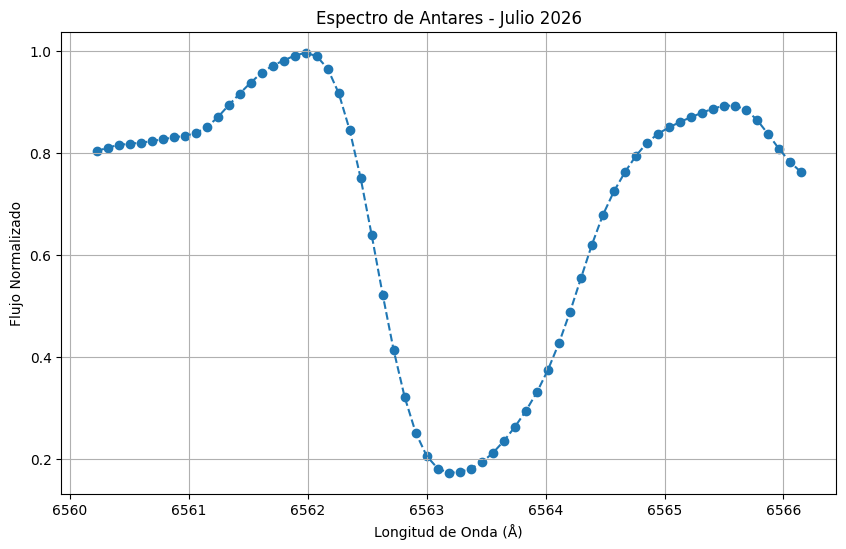

In [4]:
centro_julio = 6563.18533

indices_cercanos_julio = np.where((longitudes_observadas_julio >= centro_julio - 3) & (longitudes_observadas_julio <= centro_julio + 3))[0]


datos_cercanos_julio = pd.DataFrame({'longitud_observada': longitudes_observadas_julio[indices_cercanos_julio], 'flujo_normalizado': flujo_julio[indices_cercanos_julio]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_julio["longitud_observada"], datos_cercanos_julio["flujo_normalizado"], '--')
plt.scatter(datos_cercanos_julio["longitud_observada"], datos_cercanos_julio["flujo_normalizado"])

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Julio 2026")
plt.grid(True)
plt.show()


Obtención del perfil de absorción y emisión

In [52]:
#MODELO DE AJUSTE

# Usamos Voigt para el valle ya que permite tener en cuenta las asimetrías del perfil de la línea de absorción

def construccion_del_modelo():
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    return continuo + em_azul + valle_abs

def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox):
    p = modelo.make_params()

    borde = np.r_[flujo[:10], flujo[-10:]]
    p["cont_c"].set(value=np.median(borde), min=0, max=2)

    izquierda = longitud_onda < centro_aprox

    # Emisión azul
    i_azul = np.argmax(flujo[izquierda])
    p["em_azul_center"].set(value=longitud_onda[izquierda][i_azul],
                             min=longitud_onda.min(), max=centro_aprox)
    p["em_azul_amplitude"].set(value=1.0, min=0)
    p["em_azul_sigma"].set(value=0.4, min=0.05, max=2)

    # Absorción central
    i_min = np.argmin(flujo)
    p["valle_abs_center"].set(value=longitud_onda[i_min], min=centro_aprox - 1, max=centro_aprox + 1)
    p["valle_abs_amplitude"].set(value=-(np.median(borde) - flujo[i_min]) * 1.5, max=0)
    p["valle_abs_sigma"].set(value=0.3, min=0.03, max=1.2)
    p["valle_abs_gamma"].set(value=0.2, min=0, max=1.2, vary=True)

    return p


In [47]:
# DESCOMPOSICIÓN

def fit_y_decomposición(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado):
    longitud_onda = datos_cercanos[longitud_observada].to_numpy()
    flujo = datos_cercanos[flujo_normalizado].to_numpy()

    modelo = construccion_del_modelo()
    parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox)
    fit = modelo.fit(flujo, parametros, x=longitud_onda)

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps["em_azul_"]  
    perfil_absorcion = continuo + comps["valle_abs_"]
    residuo = flujo - fit.best_fit

    return dict(wave=longitud_onda, flux=flujo, fit=fit, comps=comps, perfil_emision=perfil_emision, perfil_absorcion=perfil_absorcion,
                residuo=residuo)

def resumen_fisico(fit):
    p = fit.params
    print("\n--- Resumen del ajuste ---")
    for comp, label in [("em_azul", "Emisión azul")]:
        c = p[f"{comp}_center"].value
        fwhm = p[f"{comp}_fwhm"].value
        amp = p[f"{comp}_height"].value
        print(f"{label:14s}: centro={c:9.3f} Å   FWHM={fwhm:5.2f} Å   altura={amp:5.3f}")

    c = p["valle_abs_center"].value
    fwhm = p["valle_abs_fwhm"].value
    profundidad = p["valle_abs_height"].value
    print(f"{'Absorción central':14s}: centro={c:9.3f} Å   FWHM={fwhm:5.2f} Å   profundidad={profundidad:5.3f}")

    print(f"\nContinuo local ajustado: {p['cont_c'].value:.3f}")
    print(f"Chi-cuadrado reducido:   {fit.redchi:.3e}")

In [48]:
# GRÁFICA

def visualizacion_decomposicion(res, titulo="Descomposición H-alpha"):
    longitud_observada, flujo, fit = res["wave"], res["flux"], res["fit"]
    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.scatter(longitud_observada, flujo, s=18, color="steelblue", label="Observado", zorder=3)
    ax.plot(longitud_observada, fit.best_fit, color="crimson", lw=1.8, label="Modelo total")
    ax.plot(longitud_observada, res["perfil_emision"], "--", color="seagreen", lw=1.5,
            label="Perfil de emisión (sin absorción)")
    ax.plot(longitud_observada, res["perfil_absorcion"], "--", color="darkorange", lw=1.5,
            label="Perfil de absorción (sin emisión)")
    ax.axhline(res["comps"]["cont_"][0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(longitud_observada, res["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda (Å)")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("halpha_emision_absorcion.png", dpi=150)
    plt.show()


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.135 Å   FWHM= 0.89 Å   altura=0.325
Absorción central: centro= 6563.304 Å   FWHM= 1.65 Å   profundidad=-0.720

Continuo local ajustado: 0.839
Chi-cuadrado reducido:   1.199e-03


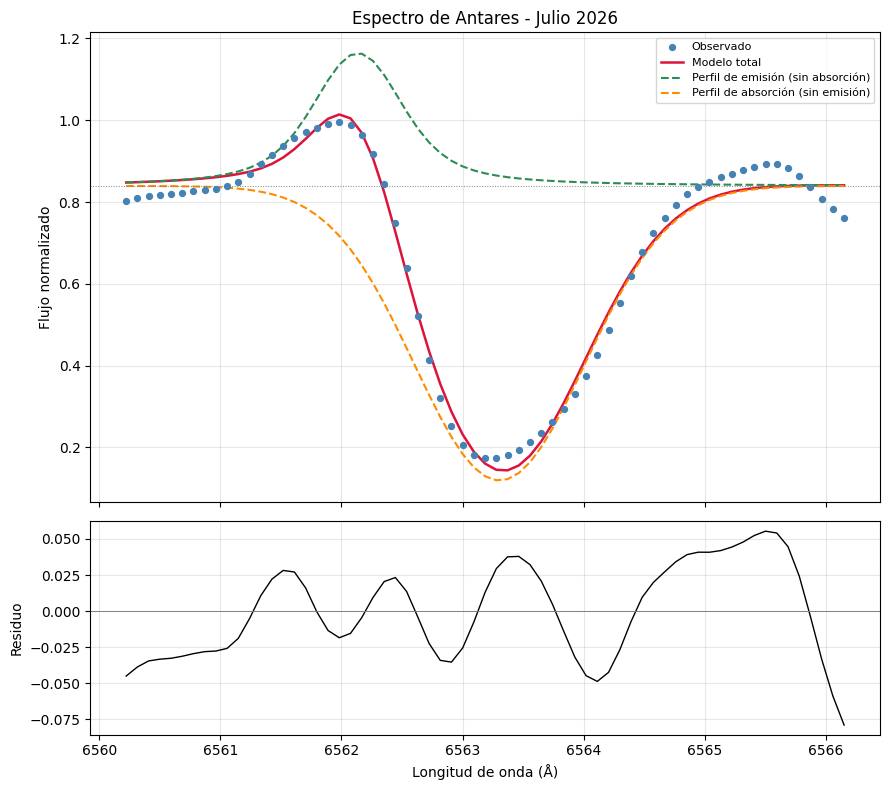

In [53]:
res = fit_y_decomposición(datos_cercanos_julio, centro_julio, "longitud_observada", "flujo_normalizado")
resumen_fisico(res["fit"])
visualizacion_decomposicion(res, titulo="Espectro de Antares - Julio 2026")